Training


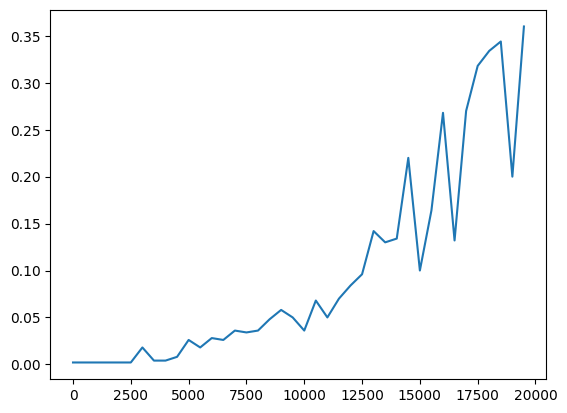

Testing


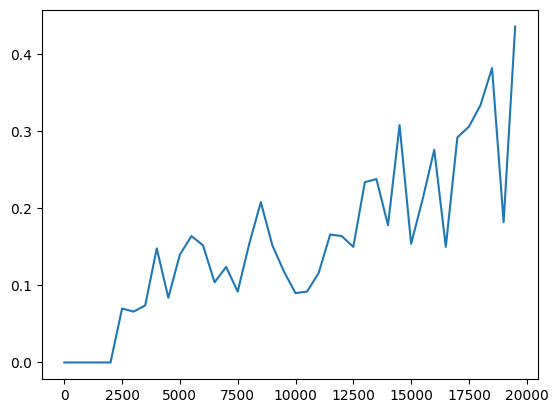

In [3]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
env = gym.make('FrozenLake-v1', desc=None, map_name="8x8", is_slippery=True, render_mode="rgb_array")

epsilon = 1
q_table = np.zeros((env.observation_space.n, env.action_space.n))
step_size = 0.2
discount = 0.95
episodes = 20000
lam = 0
found = -1
test = []
train = []

def show_ep():
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

for ep in range(episodes):
    done = False
    if found>-1:
        epsilon -= (2/(episodes-found))*epsilon
    obs, info = env.reset()
    step = 0

    while not done:
        if step>0:
            # state, action, reward
            save_info = (last_state, action, reward)
        step += 1
        last_state = obs

        action = (env.action_space.sample() if np.random.rand()<epsilon else np.argmax(q_table[obs]))
        obs, reward, terminated, truncated, info = env.step(action)
        done = truncated or terminated

        if done:
            q_table[last_state][action] += step_size* (reward - q_table[last_state][action])
            q_table[save_info[0]][save_info[1]] += step_size* (save_info[2] - q_table[save_info[0]][save_info[1]])
            train.append(reward)
            if reward>0:
                found = ep
            #show_ep()
            #print(ep,step,reward)
        elif step>1:
            q_table[save_info[0]][save_info[1]] += step_size* (save_info[2] + discount*(q_table[last_state][action]) - q_table[save_info[0]][save_info[1]])

    obs, info = env.reset()
    done = False
    while not done:
        obs, reward, terminated, truncated, info = env.step(np.argmax(q_table[obs]))
        done = truncated or terminated
        if done:
            test.append(reward)

print('Training')
window = 500
x = range(0,episodes,window)
avg_train = [float(np.mean(train[i:i+window])) for i in x]
plt.plot(x,avg_train)
plt.show()

print('Testing')
avg_test = [float(np.mean(test[i:i+window])) for i in x]
plt.plot(x,avg_test)
plt.show()

#print(q_table)